___

# <font color= #99C8F5> **Tarea FFNN: NBA** </font>
#### <font color= #2E9AFE> `Modelos No Lineales Para Pronósticos`</font>
<Strong> Sofía Maldonado, Aissa Berenice </Strong>

_15/03/2026._

___

In [76]:
# Imports
from nba_api.stats.endpoints.leaguedashteamstats import LeagueDashTeamStats
import pandas as pd
import numpy as np

from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [67]:
# Loading Data
df = pd.read_csv('warriors_data.csv')
df

,Game,Date,Opponent,Result,Warriors_Score,Opponent_Score
0,1,2024-10-23,@ Portland Trail Blazers,W,140,104
1,2,2024-10-25,@ Utah Jazz,W,127,86
2,3,2024-10-27,vs Los Angeles Clippers,L,104,112
3,4,2024-10-29,vs New Orleans Pelicans,W,124,106
4,5,2024-10-30,vs New Orleans Pelicans,W,104,89
...,...,...,...,...,...,...
77,78,2025-04-06,vs Houston Rockets,L,96,106
78,79,2025-04-08,@ Phoenix Suns,W,133,95
79,80,2025-04-09,vs San Antonio Spurs,L,111,114
80,81,2025-04-11,@ Portland Trail Blazers,W,103,86


In [68]:
df = df[['Game', 'Warriors_Score']]
df = df.rename(columns={"Warriors_Score": "ppg"})
df

,Game,ppg
0,1,140
1,2,127
2,3,104
3,4,124
4,5,104
...,...,...
77,78,96
78,79,133
79,80,111
80,81,103


In [ ]:
train_size = int(len(df)* 0.8)
train_data = df[:train_size]
test_data = df[train_size:]

scaler = MinMaxScaler(feature_range=(0,1))
train_scaled = scaler.fit_transform(train_data[['ppg']])
test_scaled = scaler.transform(test_data[['ppg']])

# Función para crear ventanas deslizantes
def crear_ventanas(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])
    return np.array(X), np.array(y)

WINDOW_SIZE = 10

X_train, y_train = crear_ventanas(train_scaled, WINDOW_SIZE)
X_test, y_test = crear_ventanas(test_scaled, WINDOW_SIZE)

X_train = X_train.reshape(X_train.shape[0], WINDOW_SIZE)
X_test = X_test.reshape(X_test.shape[0], WINDOW_SIZE)

In [74]:
last_window = test_scaled[-WINDOW_SIZE:].reshape(1, WINDOW_SIZE)
future_scaled = []

In [71]:
model = Sequential([
    Dense(32, activation='relu', input_shape=(WINDOW_SIZE,)),
    Dense(16, activation='relu'),
    Dense(1)
])

model.compile(optimizer=Adam(), loss='mse')
model.fit(X_train, y_train,
          epochs=100, validation_data=(X_test, y_test))

Epoch 1/100


/home/sofi/Documents/vscode/archivos_mnlpp/.venv/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 768ms/step - loss: 0.0830 - val_loss: 0.0773
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0801 - val_loss: 0.0641
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0728 - val_loss: 0.0588
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0724 - val_loss: 0.0558
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.0688 - val_loss: 0.0534
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.0642 - val_loss: 0.0514
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.0652 - val_loss: 0.0505
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.0636 - val_loss: 0.0504
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.0599 - val_loss: 0.0505
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0594 - val_loss: 0.0507
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0587 - val_loss: 0.0505
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0526 - val_loss: 0.0497


In [82]:
y_pred = model.predict(X_test)

y_pred_real = scaler.inverse_transform(y_pred)
y_test_real = scaler.inverse_transform(y_test.reshape(-1,1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


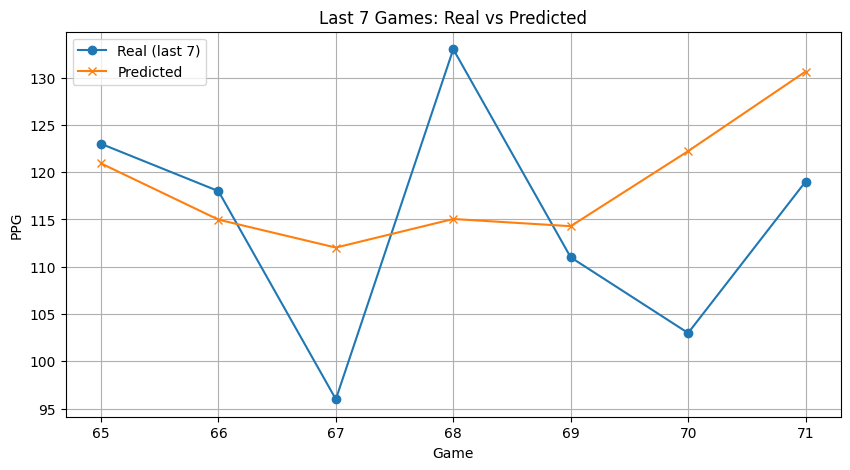

In [98]:
# x-axis for last 17 games
n = 17

test_x = np.arange(len(train_data), len(train_data) + 7)

plt.figure(figsize=(10,5))

# real last 17
plt.plot(test_x, y_test_real.flatten()[-n:], marker='o', label="Real (last 7)")

# predicted last 17
plt.plot(test_x, y_pred_real.flatten()[-n:], marker='x', label="Predicted")

plt.legend()
plt.grid()
plt.title("Last 7 Games: Real vs Predicted")
plt.xlabel("Game")
plt.ylabel("PPG")

plt.show()

In [101]:
mae = mean_absolute_error(y_test_real, y_pred_real)
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))

print(f'MAE: {mae}')
print(f'RMSE: {rmse}')

MAE: 10.459593636648998
RMSE: 12.583046057953016
